In [17]:
import pandas as pd
data = pd.read_csv('./stroke-dataset.csv')
data

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


Split the Data

In [18]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

#print(data.iloc[20])

data.fillna(0, inplace=True)

X = data.drop(['stroke'], axis=1)
y = data['stroke']

#print(X.iloc[20])
#print(y[20])

#X.index = X.gender

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1234)

#print(X_train.iloc[20])
#print(X_test.iloc[20])
#print(y_train[0])
#print(X_train.shape)
#print(X_test.shape)
#print(y_train.shape)
#print(y_test.shape)

#X.smoking_status.value_counts()

Encoding and Scalar

In [19]:
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin

nominal_columns = ['work_type']
ordinal_or_binary_columns = ['Residence_type', 'gender', 'ever_married', 'smoking_status']
irrelevant_columns = ['id']

ordinal_encoder = OrdinalEncoder(categories=[
    ['Rural', 'Urban'],
    ['Male', 'Female', 'Other'],
    ['Yes', 'No'],
    ['Unknown', 'never smoked', 'formerly smoked', 'smokes']
])

feature_encoder = make_column_transformer(
    (OneHotEncoder(), nominal_columns),
    (ordinal_encoder, ordinal_or_binary_columns),
    ('drop', irrelevant_columns),
    remainder='passthrough'
)

scaler = MinMaxScaler()

class PreprocessingTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        X_encoded = feature_encoder.fit_transform(X)
        scaler.fit(X_encoded)
        return self

    def transform(self, X, y=None):
        X_scaled = scaler.transform(feature_encoder.transform(X))
        # Return the 
        return pd.DataFrame(X_scaled, index=X.index)

preprocessing_pipeline = PreprocessingTransformer()
preprocessing_pipeline.fit_transform(X_train)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
2332,0.0,0.0,1.0,0.0,0.0,1.0,0.5,1.0,1.000000,0.841309,0.0,1.0,0.661112,0.437500
4347,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,0.333333,0.365234,0.0,0.0,0.154372,0.464139
3156,0.0,0.0,0.0,1.0,0.0,0.0,0.5,0.0,0.333333,0.353027,0.0,0.0,0.064629,0.274590
1564,0.0,0.0,1.0,0.0,0.0,0.0,0.5,0.0,0.666667,0.304199,0.0,0.0,0.063060,0.564549
12,0.0,0.0,1.0,0.0,0.0,1.0,0.5,0.0,1.000000,0.658203,0.0,0.0,0.228003,0.279713
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
664,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.333333,0.682617,0.0,0.0,0.120303,0.275615
3276,0.0,0.0,0.0,1.0,0.0,1.0,0.5,0.0,0.000000,0.963379,0.0,0.0,0.107100,0.327869
1318,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.333333,0.609375,0.0,1.0,0.141723,0.326844
723,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.000000,0.609375,0.0,0.0,0.104007,0.250000


Cross Val Function

In [82]:
from sklearn.metrics import get_scorer, fbeta_score
import numpy as np

def cross_validate_and_predict(model, X_train, y_train, metrics, cv_folds=5, random_state=1234):
    # Convert metrics to functions if they are strings
    metric_fns = [metric if callable(metric) else get_scorer(metric)._score_func for metric in metrics]
    kfold = KFold(n_splits=cv_folds, shuffle=True, random_state=random_state)
    y_preds = np.zeros(y_train.shape)
    results = []
    fold = 1
    for train_idx, test_idx in kfold.split(X_train):
        model.fit(X_train.iloc[train_idx], y_train.iloc[train_idx])
        y_pred = model.predict(X_train.iloc[test_idx])
        y_preds[test_idx] = y_pred
        fold_results = {'fold': fold}
        for metric_name, metric_fn in zip(metrics, metric_fns):
            value = metric_fn(y_train.iloc[test_idx], y_pred)
            fold_results[metric_name] = value
        fold_results["f2"] = fbeta_score(y_train.iloc[test_idx], y_pred, beta=2)
        results.append(fold_results)
        fold += 1
    return pd.DataFrame(results), y_preds

Model

In [104]:
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate
from sklearn.model_selection import cross_val_predict

from sklearn.model_selection import KFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix



scoring_metrics = []

scoring_metrics.append('accuracy')
scoring_metrics.append('precision')
scoring_metrics.append('recall')
scoring_metrics.append('f1')
scoring_metrics.append('average_precision')

k_fold = KFold(n_splits=5, random_state=1234, shuffle=True)


svm_classifier = SVC(C=1, gamma= .05, random_state=1234)
svm_pipeline = make_pipeline(feature_encoder, scaler, svm_classifier)

#svm_performance = cross_val_predict(svm_pipeline, X_train, y=y_train, cv=k_fold)

#print(classification_report(y_train, svm_performance))
#print(confusion_matrix(y_train, svm_performance))
#pd.DataFrame(svm_performance)

svm_performance, svm_pred = cross_validate_and_predict(
    svm_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, svm_pred))
print(confusion_matrix(y_train, svm_pred))

svm_performance

c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(resu

              precision    recall  f1-score   support

           0       0.95      1.00      0.98      3890
           1       0.00      0.00      0.00       198

    accuracy                           0.95      4088
   macro avg       0.48      0.50      0.49      4088
weighted avg       0.91      0.95      0.93      4088

[[3890    0]
 [ 198    0]]


c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\camz\Documents\code\alda-project\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize(

,fold,accuracy,precision,recall,f1,average_precision,f2
0,1,0.958435,0.0,0.0,0.0,0.041565,0.0
1,2,0.953545,0.0,0.0,0.0,0.046455,0.0
2,3,0.937653,0.0,0.0,0.0,0.062347,0.0
3,4,0.952264,0.0,0.0,0.0,0.047736,0.0
4,5,0.955936,0.0,0.0,0.0,0.044064,0.0


Same thing but with SMOTE

In [105]:
from imblearn.over_sampling import SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline


string_cols = X_train.select_dtypes(include=['object']).columns
string_cols_indices = [X_train.columns.get_loc(col) for col in string_cols]

smote = SMOTENC(string_cols_indices, random_state=1234)
smote_svm_pipeline = ImbPipeline([("SMOTE", smote), ("SVM", svm_pipeline)])

#smote_svm_performance = cross_val_predict(smote_svm_pipeline, X_train, y=y_train, cv=k_fold)

#print(classification_report(y_train, smote_svm_performance))
#print(confusion_matrix(y_train, smote_svm_performance))

smote_svm_performance, smote_svm_pred = cross_validate_and_predict(
    smote_svm_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, smote_svm_pred))
print(confusion_matrix(y_train, smote_svm_pred))

smote_svm_performance

              precision    recall  f1-score   support

           0       0.97      0.76      0.85      3890
           1       0.11      0.60      0.19       198

    accuracy                           0.75      4088
   macro avg       0.54      0.68      0.52      4088
weighted avg       0.93      0.75      0.82      4088

[[2949  941]
 [  79  119]]


,fold,accuracy,precision,recall,f1,average_precision,f2
0,1,0.767726,0.097938,0.558824,0.166667,0.073068,0.287879
1,2,0.751834,0.089552,0.473684,0.150628,0.066869,0.254958
2,3,0.738386,0.147186,0.666667,0.241135,0.118906,0.390805
3,4,0.742962,0.116592,0.666667,0.198473,0.093640,0.343008
4,5,0.751530,0.104265,0.611111,0.178138,0.080854,0.309859


Same thing but oversampling

In [106]:
from imblearn.over_sampling import RandomOverSampler

oversampler = RandomOverSampler(sampling_strategy="minority")
oversampled_svm_pipeline = ImbPipeline([("Over Sampler", oversampler), ("SVM", svm_pipeline)])

#oversampled_svm_performance = cross_val_predict(oversampled_svm_pipeline, X_train, y=y_train, cv=k_fold)

#print(classification_report(y_train, oversampled_svm_performance))
#print(confusion_matrix(y_train, oversampled_svm_performance))

X_train_resampled, y_train_resampled = oversampler.fit_resample(X_train, y_train)

print("Shape of X_train_resampled", X_train_resampled.shape)
print("Number of duplicated instances in X_train_resampled", X_train_resampled.duplicated().sum())
print("Percent of y_train_resampled that is positive class:", y_train_resampled.mean())

oversampled_svm_performance, oversampled_svm_pred = cross_validate_and_predict(
    oversampled_svm_pipeline, X_train, y_train, scoring_metrics
)

print(classification_report(y_train, oversampled_svm_pred))
print(confusion_matrix(y_train, oversampled_svm_pred))

oversampled_svm_performance


Shape of X_train_resampled (7780, 11)
Number of duplicated instances in X_train_resampled 3692
Percent of y_train_resampled that is positive class: 0.5
              precision    recall  f1-score   support

           0       0.99      0.73      0.84      3890
           1       0.13      0.82      0.23       198

    accuracy                           0.73      4088
   macro avg       0.56      0.77      0.53      4088
weighted avg       0.95      0.73      0.81      4088

[[2821 1069]
 [  35  163]]


,fold,accuracy,precision,recall,f1,average_precision,f2
0,1,0.724939,0.116466,0.852941,0.204947,0.105451,0.376623
1,2,0.721271,0.100840,0.631579,0.173913,0.080804,0.307692
2,3,0.732274,0.171875,0.862745,0.286645,0.156842,0.478261
3,4,0.723378,0.136187,0.897436,0.236486,0.127115,0.423729
4,5,0.747858,0.133621,0.861111,0.231343,0.121182,0.412234


Confusion Matrices

T = Stroke
F = No Stroke

SVM:

|    | T |   F  |
|----|---|------|
|  T | 0 |  198 |
|  F | 0 | 3890 |

SMOTE:

|    |  T  |   F  |
|----|-----|------|
|  T | 119 |   79 |
|  F | 941 | 2949 |

Oversampled:

|    |  T   |   F  |
|----|------|------|
|  T |  160 |   38 |
|  F | 1067 | 2823 |


Show Performances

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

def plot_performances(named_performances):
    # Concatenate all the results DataFrames into a single dataframe
    all_performances = None
    for model_name, performance in named_performances:
        performance = performance.copy()
        # Add a column for the "model" so we know which results belong to which
        performance['model'] = model_name
        if all_performances is None:
            all_performances = performance
        else:
            all_performances = pd.concat([all_performances, performance])
    # Remove the "fold" attribute, so we don't graph it
    all_performances.drop('fold', axis=1, inplace=True)
    # Melt the data, so its in a "long" format instead of a "wide" format,
    # which seaborn prefers.
    performances_melted = all_performances.melt(id_vars=['model'], var_name='metric', value_name='score')
    
    # Use Seaborn/matplot to plot the comparative boxplots
    plt.figure(figsize=(12, 6))
    # The x-axis is the metric, the y-axis is the score, and the hue is the model
    sns.boxplot(data=performances_melted, x='metric', y='score', hue='model')
    # Always use 0-1 for the y-axis.
    plt.ylim(0, 1)
    plt.title('Model Performances')
    plt.ylabel('Score')
    plt.xticks(rotation=45)
    plt.show()

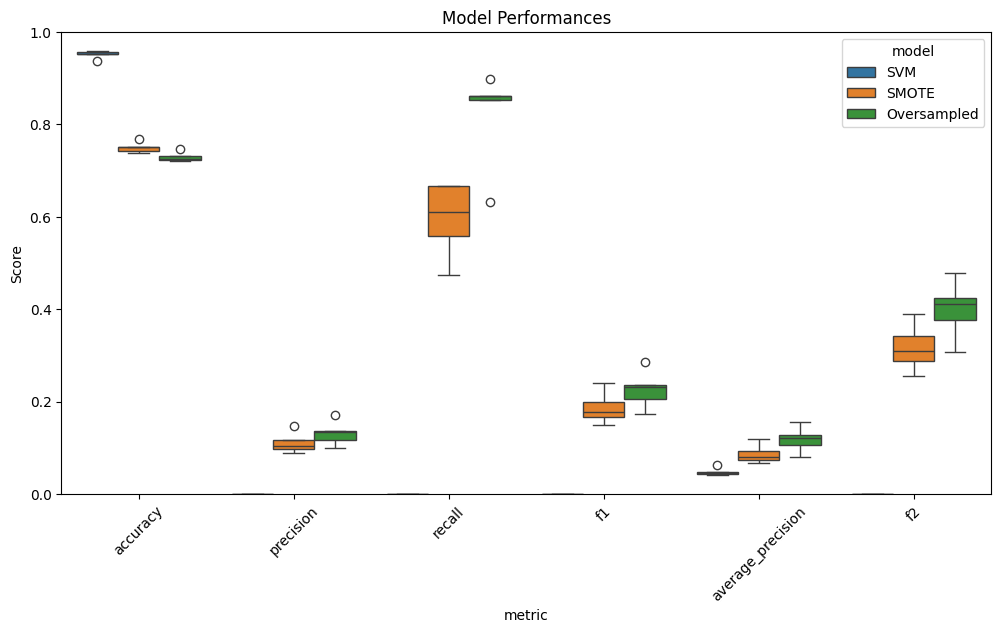

In [107]:
plot_performances([
    ('SVM', svm_performance),
    ('SMOTE', smote_svm_performance),
    ('Oversampled', oversampled_svm_performance)
])

Going with oversampled because it performs the best on most metrics, especially the one we care most about (f1 score)

## Hyperparameter Tuning

Next then is to start tuning the hyperparameters Gamma and C. 


In [87]:
from sklearn.model_selection import GridSearchCV
svm_step_name = f"{oversampled_svm_pipeline.steps[1][0]}__{oversampled_svm_pipeline.steps[1][1].steps[2][0]}"
svm_step_prefix = f"{svm_step_name}__"

svm_c = f"{svm_step_prefix}C"
svm_gamma = f"{svm_step_prefix}gamma"
svm_degree = f"{svm_step_prefix}degree"
svm_kernel = f"{svm_step_prefix}kernel"


print(svm_step_prefix)

SVM__svc__


In [ ]:
def explore_single_hp_values(pipeline, param_name, param_values, X_train, y_train, k_fold, scoring):
    param_grid = {param_name: param_values}
    grid_search = GridSearchCV(pipeline, param_grid, cv=k_fold, scoring=scoring)
    grid_search.fit(X_train, y_train)
    result_columns = [f"param_{param_name}", "mean_test_score", "std_test_score", "rank_test_score"]
    return pd.DataFrame(grid_search.cv_results_)[result_columns]


In [95]:
explore_single_hp_values(oversampled_svm_pipeline, svm_c, [.375, .5, .625, .75], X_train, y_train, k_fold, 'f1')

,param_SVM__svc__C,mean_test_score,std_test_score,rank_test_score
0,0.375,0.223887,0.036308,2
1,0.500,0.223646,0.042038,3
2,0.625,0.225533,0.041300,1
3,0.750,0.222909,0.037251,4


In [ ]:
explore_single_hp_values(oversampled_svm_pipeline, svm_gamma, [1, 0.1, 0.01, 0.001], X_train, y_train, k_fold, 'f1')


,param_SVM__svc__gamma,mean_test_score,std_test_score,rank_test_score
0,1.0000,0.181460,0.042487,3
1,0.1000,0.224446,0.045466,1
2,0.0100,0.219379,0.035785,2
3,0.0010,0.162202,0.031618,4
4,0.0001,0.147462,0.017207,5


In [ ]:
explore_single_hp_values(oversampled_svm_pipeline, svm_degree, [3, 5, 7], X_train, y_train, k_fold, 'f1')


,param_SVM__svc__degree,mean_test_score,std_test_score,rank_test_score
0,3,0.225645,0.039524,3
1,4,0.225470,0.040908,4
2,5,0.228237,0.042797,1
3,6,0.220893,0.033128,5
4,7,0.226179,0.040655,2


In [100]:
explore_single_hp_values(oversampled_svm_pipeline, svm_kernel, ['rbf', 'linear', 'sigmoid'], X_train, y_train, k_fold, 'f1')


,param_SVM__svc__kernel,mean_test_score,std_test_score,rank_test_score
0,rbf,0.225343,0.034202,2
1,linear,0.237658,0.044677,1
2,sigmoid,0.223380,0.040661,3


In [ ]:
from sklearn.metrics import make_scorer
param_grid = {
    'SVM__svc__C': [.5, 1, 10, 100, 1000],
    'SVM__svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'SVM__svc__kernel': ['linear'],
    'SVM__svc__class_weight': [{1:0.95,0:0.05}]
}

svm_param_grid = {
    'svc__C': [.5, 1, 10, 100, 1000],
    'svc__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'svc__kernel': ['linear'],
    'svc__class_weight': [{1:0.95,0:0.05}]
}

# grid_search = GridSearchCV(svm_pipeline, svm_param_grid, scoring=make_scorer(fbeta_score, beta=2), cv=k_fold).fit(X_train, y_train)
grid_search = GridSearchCV(oversampled_svm_pipeline, param_grid, scoring=make_scorer(fbeta_score, beta=2), cv=k_fold).fit(X_train, y_train)

# Print the best parameters
grid_search.best_params_

Grid Search Results (10 min) (My Ranges, not great)  

{'SVM__svc__C': 0.625,  
 'SVM__svc__degree': 3,  
 'SVM__svc__gamma': 0.001,  
 'SVM__svc__kernel': 'linear'}  


GS Results (25 min) (Regular exponentials with oversampling)  
{'SVM__svc__C': 100, 'SVM__svc__gamma': 0.0001, 'SVM__svc__kernel': 'linear'}  


GS (1m) (Using class weight rather than oversampling)  
{'svc__C': 10,  
 'svc__class_weight': {1: 0.95, 0: 0.05},  
 'svc__gamma': 1,  
 'svc__kernel': 'linear'}  

GS (25 min) (Regular exponentials with class weight too)  
{'SVM__svc__C': 10,
 'SVM__svc__class_weight': {1: 0.95, 0: 0.05},
 'SVM__svc__gamma': 0.1,
 'SVM__svc__kernel': 'linear'}

In [133]:
hp_svm_classifier = SVC(C=10, gamma=0.1, kernel='linear', class_weight = {1:0.65,0:0.35})
hp_svm_pipeline = make_pipeline(feature_encoder, scaler, hp_svm_classifier)
hp_svm_overs_pipeline = ImbPipeline([("Oversampler", oversampler), ("hp rf", hp_svm_pipeline)])

hp_overs_svm_performance, hp_overs_svm_pred = cross_validate_and_predict(
    hp_svm_overs_pipeline, X_train, y_train, scoring_metrics
)
print(classification_report(y_train, hp_overs_svm_pred))
print(confusion_matrix(y_train, hp_overs_svm_pred))
hp_overs_svm_performance


              precision    recall  f1-score   support

           0       0.99      0.62      0.77      3890
           1       0.11      0.89      0.19       198

    accuracy                           0.64      4088
   macro avg       0.55      0.76      0.48      4088
weighted avg       0.95      0.64      0.74      4088

[[2426 1464]
 [  21  177]]


,fold,accuracy,precision,recall,f1,average_precision,f2
0,1,0.639364,0.095975,0.911765,0.173669,0.091174,0.337691
1,2,0.649144,0.086379,0.684211,0.153392,0.073771,0.286976
2,3,0.629584,0.137931,0.941176,0.240602,0.133485,0.434783
3,4,0.607099,0.106145,0.974359,0.191436,0.104648,0.369650
4,5,0.658507,0.109325,0.944444,0.195965,0.105699,0.373626


In [ ]:

def calculate_f2_score(precision, recall):     return ((1 + 2**2) * precision * recall) / (2**2 * precision + recall)
def calculate_f1_score(precision, recall):     return (2 * precision * recall) / (precision + recall)

hp_svm_classifier = SVC(C=10, gamma=1, kernel='linear', class_weight = {1:0.95,0:0.05})
hp_svm_pipeline = make_pipeline(feature_encoder, scaler, hp_svm_classifier)

hp_svm_performance, hp_svm_pred = cross_validate_and_predict(
    hp_svm_pipeline, X_train, y_train, scoring_metrics
)
class_report = classification_report(y_train, hp_svm_pred, output_dict=True)
print(class_report)
print(classification_report(y_train, hp_svm_pred))
print(confusion_matrix(y_train, hp_svm_pred))

# print(calculate_f1_score(class_report['0']['precision'], class_report['0']['recall']))
print(calculate_f2_score(class_report['0']['precision'], class_report['0']['recall']))
print(calculate_f2_score(class_report['1']['precision'], class_report['1']['recall']))

{'0': {'precision': 0.9879725085910653, 'recall': 0.7390745501285347, 'f1-score': 0.8455882352941176, 'support': 3890.0}, '1': {'precision': 0.13837011884550085, 'recall': 0.8232323232323232, 'f1-score': 0.2369186046511628, 'support': 198.0}, 'accuracy': 0.7431506849315068, 'macro avg': {'precision': 0.5631713137182831, 'recall': 0.7811534366804289, 'f1-score': 0.5412534199726402, 'support': 4088.0}, 'weighted avg': {'precision': 0.94682249069243, 'recall': 0.7431506849315068, 'f1-score': 0.8161076612072035, 'support': 4088.0}}
              precision    recall  f1-score   support

           0       0.99      0.74      0.85      3890
           1       0.14      0.82      0.24       198

    accuracy                           0.74      4088
   macro avg       0.56      0.78      0.54      4088
weighted avg       0.95      0.74      0.82      4088

[[2875 1015]
 [  35  163]]
0.8455882352941176
0.778289117487818
0.4137055837563452


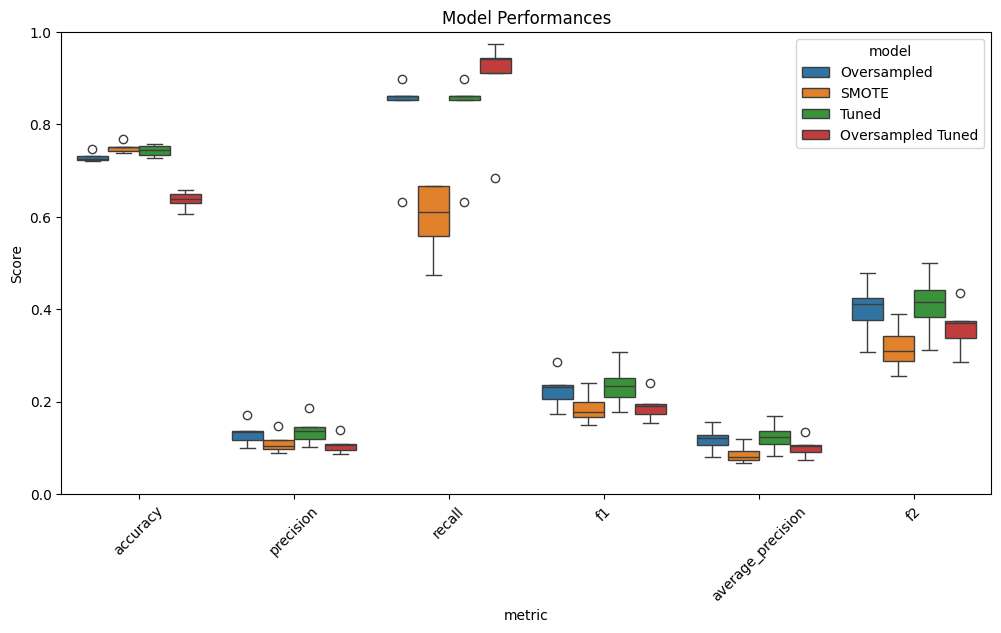

In [134]:
plot_performances([
    ('Oversampled', oversampled_svm_performance),
    ('SMOTE', smote_svm_performance),
    ('Tuned', hp_svm_performance),
    ('Oversampled Tuned', hp_overs_svm_performance),
])

## Final Model w/ Testing Data

In [144]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, fbeta_score
def f2_metric(y_true, y_pred):
    return fbeta_score(y_true, y_pred, beta=2)

def evaluate_pipelines_holdout(pipelines, X_train, y_train, X_evaluate, y_evaluate):
    rows = []
    for name, pipeline in pipelines:
        pipeline.fit(X_train, y_train)
        test_predictions = pipeline.predict(X_evaluate)
        row = {'name': name}
        for metric in [accuracy_score, precision_score, recall_score, f1_score, f2_metric]:
            metric_name = metric.__name__
            row[f'eval_{metric_name}'] = metric(y_evaluate, test_predictions)
        rows.append(row)
    return pd.DataFrame(rows)

In [152]:
hp_svm_classifier = SVC(C=10, gamma=1, kernel='linear', class_weight = {1:0.95,0:0.05})
hp_svm_pipeline = make_pipeline(feature_encoder, scaler, hp_svm_classifier)

hp_svm_pipeline.fit(X_train, y_train)
y_pred_svm = hp_svm_pipeline.predict(X_test)
report = classification_report(y_test, y_pred_svm)

print(report)

# svm_results = evaluate_pipelines_holdout(
#     [("svm", hp_svm_pipeline)], X_train, y_train, X_test, y_test
# )
class_report = classification_report(y_test, y_pred_svm, output_dict=True)
print(class_report)

print(calculate_f2_score(class_report['0']['precision'], class_report['0']['recall']))
print(calculate_f2_score(class_report['1']['precision'], class_report['1']['recall']))

              precision    recall  f1-score   support

           0       0.98      0.75      0.85       971
           1       0.14      0.76      0.23        51

    accuracy                           0.75      1022
   macro avg       0.56      0.76      0.54      1022
weighted avg       0.94      0.75      0.82      1022

{'0': {'precision': 0.9837618403247632, 'recall': 0.748712667353244, 'f1-score': 0.8502923976608188, 'support': 971.0}, '1': {'precision': 0.13780918727915195, 'recall': 0.7647058823529411, 'f1-score': 0.23353293413173654, 'support': 51.0}, 'accuracy': 0.7495107632093934, 'macro avg': {'precision': 0.5607855138019576, 'recall': 0.7567092748530926, 'f1-score': 0.5419126658962776, 'support': 1022.0}, 'weighted avg': {'precision': 0.9415469819046788, 'recall': 0.7495107632093934, 'f1-score': 0.8195147727684673, 'support': 1022.0}}
0.7862859614968635
0.4004106776180698
